# Brain-to-Text Metrics v2

This notebook evaluates NeuroVLM brain-to-text generation separately from text-to-brain. It keeps the semantic metrics from `new_neuropvlm_metrics_v2`, removes the cleaned abstract branch, adds Recall@1 retrieval, and adds network label accuracy for the Networks test set.

To scale from a smoke run to the whole available test set, set `MAX_B2T = None`.

In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import re
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from neurovlm import NeuroVLM
from neurovlm.data import load_dataset, load_latent
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer, util as st_util
from transformers import AutoModel, AutoTokenizer


In [2]:
LLM_BACKEND = "ollama"
LLM_MODEL = "qwen2.5:7b-instruct"
BERTSCORE_MODEL = "microsoft/deberta-xlarge-mnli"

MAX_B2T = 30          # set to None for the full available test set
RUN_NETWORKS = True
RUN_PUBMED = True
RUN_NEUROVAULT = True

B2T_TOP_K = 5
B2T_SIM_THR = 0.35
B2T_DATASETS = ["llm_neuro_terms", "kg_mesh", "cogatlas"]
OUTPUT_DIR = Path("docs/03_evaluation/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Pre-download Hugging Face assets used by BERTScore so metric calls do not
# repeatedly block on tokenizer/model metadata requests during the eval loop.
def predownload_hf_model(model_name: str):
    print(f"Pre-downloading Hugging Face model for BERTScore: {model_name}")
    AutoTokenizer.from_pretrained(model_name, use_fast=False)
    AutoModel.from_pretrained(model_name)
    print("BERTScore model is cached.")

predownload_hf_model(BERTSCORE_MODEL)


Pre-downloading Hugging Face model for BERTScore: microsoft/deberta-xlarge-mnli


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 1e582392-9c4c-4aef-bf38-4fff0dde1b3c)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 391c49c4-a9f8-4201-a17d-2c27ae1545f7)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: e924016a-01ea-4d2d-87ad-62abe31109c7)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/main/config.json
Retrying in 4s [Retry 3/5].


BERTScore model is cached.


In [4]:
nvlm = NeuroVLM()
_st_model = SentenceTransformer("all-MiniLM-L6-v2")
print("Ready.")

Ready.


In [5]:
def resolve_network_test_set_path():
    candidates = [
        Path("network_test_set_labels.csv"),
        Path("docs/03_evaluation/network_test_set_labels.csv"),
        Path.cwd() / "network_test_set_labels.csv",
        Path.cwd() / "docs/03_evaluation/network_test_set_labels.csv",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find network_test_set_labels.csv. Run "
        "23_create_networks_test_set_csv.ipynb first, or set NETWORK_TEST_SET_PATH "
        "to the CSV location. Checked: " + ", ".join(str(c) for c in candidates)
    )


NETWORK_TEST_SET_PATH = resolve_network_test_set_path()
network_labels_df = pd.read_csv(NETWORK_TEST_SET_PATH)
network_labels_df = network_labels_df[network_labels_df["network_key"] != "unknown"].copy()

# One row per canonical network, derived from the network test-set CSV.
network_info = (
    network_labels_df
    .sort_values(["network_key", "raw_network_label"])
    .groupby("network_key", as_index=False)
    .agg(
        display=("network_name", "first"),
        short_definition=("short_definition", "first"),
        long_definition=("long_definition", "first"),
        mapped_terms=("mapped_terms", "first"),
        raw_aliases=("raw_network_label", lambda s: "; ".join(sorted(set(map(str, s))))),
    )
)

DISPLAY_TO_KEY = dict(zip(network_info["display"], network_info["network_key"]))
KEY_TO_DISPLAY = dict(zip(network_info["network_key"], network_info["display"]))
SHORT_LABELS = dict(zip(network_info["display"], network_info["short_definition"]))
LONG_LABELS = dict(zip(network_info["display"], network_info["long_definition"]))

print(f"Loaded {len(network_info)} canonical network labels from {NETWORK_TEST_SET_PATH.resolve()}")
display(network_info[["network_key", "display", "short_definition"]])

Loaded 8 canonical network labels from /Users/borng/code/lab_work/neurovlm/docs/03_evaluation/network_test_set_labels.csv


,network_key,display,short_definition
0,attention,Attention,Dorsal attention network for selective attenti...
1,auditory,Auditory,"Auditory network for auditory perception, soun..."
2,cingulo_opercular,Cingulo-Opercular,Cingulo-opercular/salience network for salienc...
3,default_mode,Default Mode,Default mode network for self-referential thou...
4,frontoparietal_control,Frontoparietal Control,Frontoparietal control network for executive c...
5,language,Language,"Language network for speech comprehension, spe..."
6,motor,Motor,"Sensorimotor network for movement planning, vo..."
7,visual,Visual,"Visual network for visual perception, object r..."


In [6]:
_LABEL_TO_DU = {
    "Language": "LANG",
    "Auditory": "AUD",
    "Default Mode": "DN-A",
    "Frontoparietal Control": "FPN-A",
    "Attention": "dATN-A",
    "Visual": "VIS-C",
    "Motor": "SMOT-A",
    "Cingulo-Opercular": "CG-OP",
}

def _normalize_expected_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text or "")).strip()

all_net_latents = load_latent("networks_neuro")
du = all_net_latents["Du"]
networks_data = {
    label: {
        "latent": du[du_key],
        "short_gt": _normalize_expected_text(SHORT_LABELS[label]),
        "long_gt": _normalize_expected_text(LONG_LABELS[label]),
        "network_key": DISPLAY_TO_KEY[label],
    }
    for label, du_key in _LABEL_TO_DU.items()
    if du_key in du and label in DISPLAY_TO_KEY
}
print(f"Networks loaded: {list(networks_data)}")

Networks loaded: ['Language', 'Auditory', 'Default Mode', 'Frontoparietal Control', 'Attention', 'Visual', 'Motor', 'Cingulo-Opercular']


In [7]:
# PubMed summaries dataset: use summary text as long-form ground truth.
# These summaries better match the desired B2T LLM output than full abstracts.
df_summaries = load_dataset("pubmed_summaries")
df_pubs = load_dataset("pubmed_text")

if "test" in df_summaries.columns:
    df_test = df_summaries[df_summaries["test"].fillna(False).astype(bool)].reset_index(drop=True)
else:
    print("WARNING: no test column found in pubmed_summaries; using full summaries table as a test proxy.")
    df_test = df_summaries.copy().reset_index(drop=True)

_pmid_col = "pmid" if "pmid" in df_test.columns else df_test.columns[0]
_summary_col = "summary" if "summary" in df_test.columns else "description"
_title_col = "title" if "title" in df_test.columns else ("name" if "name" in df_test.columns else None)

# Fill title from publications by PMID if summaries do not carry title/name.
_pub_pmid_col = "pmid" if "pmid" in df_pubs.columns else df_pubs.columns[0]
_pub_title_col = "name" if "name" in df_pubs.columns else ("title" if "title" in df_pubs.columns else None)
pub_title_lookup = {}
if _pub_title_col is not None:
    pub_title_lookup = (
        df_pubs
        .assign(_pmid_key=lambda df: df[_pub_pmid_col].astype(str))
        .drop_duplicates("_pmid_key")
        .set_index("_pmid_key")[_pub_title_col]
        .astype(str)
        .to_dict()
    )

pubmed_latents, pubmed_pmids = load_latent("pubmed_images")
pubmed_pmids = np.asarray(pubmed_pmids).astype(str)
test_pmids = df_test[_pmid_col].astype(str).values
mask = np.isin(pubmed_pmids, test_pmids)
aligned_latents = pubmed_latents[mask]
aligned_pmids = pubmed_pmids[mask]

pmid_to_row = (
    df_test
    .assign(_pmid_key=lambda df: df[_pmid_col].astype(str))
    .drop_duplicates("_pmid_key")
    .set_index("_pmid_key")
)

pubmed_data = []
for i, pmid in enumerate(aligned_pmids):
    if pmid not in pmid_to_row.index:
        continue
    row = pmid_to_row.loc[pmid]
    title = str(row[_title_col]) if _title_col is not None and _title_col in row.index else pub_title_lookup.get(pmid, "")
    summary = str(row[_summary_col]) if _summary_col in row.index else ""
    pubmed_data.append({
        "pmid": pmid,
        "latent": aligned_latents[i],
        "short_gt": title,
        "long_gt": summary,
    })

pubmed_eval = pubmed_data[:MAX_B2T] if MAX_B2T else pubmed_data
print(f"PubMed summary test samples: {len(pubmed_eval)} / {len(pubmed_data)}")
print(f"Summaries table rows: {len(df_summaries):,}; test rows: {len(df_test):,}")

neuro_summaries.parquet:   0%|          | 0.00/44.3M [00:00<?, ?B/s]

publications.parquet:   0%|          | 0.00/27.5M [00:00<?, ?B/s]

PubMed summary test samples: 30 / 2987
Summaries table rows: 30,826; test rows: 3,945


In [8]:
df_nv = load_dataset("neurovault_text")
df_nv_meta = load_dataset("neurovault_images_meta")
nv_latents = load_latent("neurovault_images")

_doi_pub = "doi" if "doi" in df_nv.columns else df_nv.columns[0]
_doi_meta = "doi" if "doi" in df_nv_meta.columns else df_nv_meta.columns[0]
_title_nv = "title" if "title" in df_nv.columns else df_nv.columns[1]
_abs_nv = "abstract" if "abstract" in df_nv.columns else df_nv.columns[2]

neurovault_data = []
for _, pub_row in df_nv.iterrows():
    doi = pub_row[_doi_pub]
    img_indices = np.where((df_nv_meta[_doi_meta] == doi).values)[0]
    if len(img_indices) == 0 or img_indices[0] >= len(nv_latents):
        continue
    neurovault_data.append({
        "doi": doi,
        "latent": nv_latents[int(img_indices[0])],
        "short_gt": str(pub_row[_title_nv]),
        "long_gt": str(pub_row[_abs_nv]),
    })

neurovault_eval = neurovault_data[:MAX_B2T] if MAX_B2T else neurovault_data
print(f"NeuroVault samples: {len(neurovault_eval)} / {len(neurovault_data)}")

NeuroVault samples: 30 / 312


## Metric Helpers

`nvlm_sim` is a cosine similarity in NeuroVLM's shared latent space. A value around 0.33 can be meaningful because it is measured against a broad retrieval space, so the notebook plots it with empirical quartiles and a random-pair baseline rather than treating 1.0 as the only intuitive target.

In [9]:
def _semantic_sim(gen: str, gt: str) -> float:
    emb1 = _st_model.encode(gen, convert_to_tensor=True)
    emb2 = _st_model.encode(gt, convert_to_tensor=True)
    return float(st_util.cos_sim(emb1, emb2))


def _bertscore_single(generated: str, reference: str):
    p, r, f1 = bert_score(
        cands=[generated],
        refs=[reference],
        lang="en",
        model_type=BERTSCORE_MODEL,
        verbose=False,
    )
    return float(p[0]), float(r[0]), float(f1[0])


def _nvlm_latent_sim(brain_query_emb: torch.Tensor, generated: str) -> float:
    nvlm._ensure_projection_heads()
    with torch.no_grad():
        raw_emb = nvlm._encode_text(generated)
        z_text = nvlm._proj_head_text_infonce(raw_emb.to(nvlm.device))
        z_text = F.normalize(z_text, dim=-1).cpu()
    z_brain = brain_query_emb.cpu()
    if z_brain.dim() == 1:
        z_brain = z_brain.unsqueeze(0)
    return float(F.cosine_similarity(z_brain, z_text))


def _format_context_summary(table):
    lines = []
    for _, row in table.iterrows():
        lines.append(f"[{row.get('dataset', '?')}] sim={row.get('cosine_similarity', float('nan')):.3f} | {row.get('title', '')}")
    return "\n".join(lines)


def _b2t_once(table, user_prompt, gt_text, max_tokens, brain_query_emb):
    generated = nvlm.generate_llm_response(
        backend=LLM_BACKEND,
        model_name=LLM_MODEL,
        table=table,
        user_prompt=user_prompt,
        max_new_tokens=max_tokens,
        verbose=False,
    )
    bert_p, bert_r, bert_f1 = _bertscore_single(generated, gt_text)
    return {
        "generated": generated,
        "gt_text": gt_text,
        "bert_p": bert_p,
        "bert_r": bert_r,
        "bert_f1": bert_f1,
        "sem_sim": _semantic_sim(generated, gt_text),
        "nvlm_sim": _nvlm_latent_sim(brain_query_emb, generated),
    }


def run_b2t(name, latent, short_gt, long_gt, short_prompt, long_prompt="", short_tokens=64, long_tokens=512):
    try:
        result = nvlm.brain(latent).to_text(datasets=B2T_DATASETS)
        all_table = result.top_k(B2T_TOP_K)
        table = all_table[all_table["cosine_similarity"] > B2T_SIM_THR]
        if table.empty:
            table = all_table
        if len(table) > B2T_TOP_K:
            table = table.nlargest(B2T_TOP_K, "cosine_similarity").reset_index(drop=True)

        records = []
        for mode, prompt, gt, tokens in [
            ("short", short_prompt, short_gt, short_tokens),
            ("long", long_prompt, long_gt, long_tokens),
        ]:
            rec = _b2t_once(table, prompt, gt, tokens, result.query_embeddings)
            rec.update({"name": name, "mode": mode, "context_summary": _format_context_summary(table)})
            records.append(rec)
        return records
    except Exception as e:
        print(f"[B2T error] {name}: {type(e).__name__}: {e}")
        traceback.print_exc()
        return []


SHORT_PROMPT_GENERAL = (
    "Reply with a single concise sentence (10-20 words) naming the main cognitive "
    "function or brain network. Output only that sentence."
)
SHORT_PROMPT_PUBMED = (
    "Generate only a paper title (6-12 words) for the neuroimaging study this "
    "brain activation pattern represents. Output the title only."
)
LONG_PROMPT = ""

In [10]:
def normalize_label_text(text: str) -> str:
    return re.sub(r"[^a-z0-9]+", " ", str(text).lower()).strip()


def _network_aliases(row):
    aliases = []
    for value in [row["display"], row.get("mapped_terms", ""), row.get("raw_aliases", "")]:
        aliases.extend([normalize_label_text(x) for x in str(value).split(";")])
    aliases.append(normalize_label_text(row["network_key"].replace("_", " ")))
    return [x for x in dict.fromkeys(aliases) if x]


NETWORK_LABEL_ROWS = network_info.to_dict("records")
NETWORK_ALIAS_MAP = {row["network_key"]: _network_aliases(row) for row in NETWORK_LABEL_ROWS}


def predict_network_label(text: str, min_semantic_margin=0.02):
    text_norm = normalize_label_text(text)
    alias_hits = []
    for key, aliases in NETWORK_ALIAS_MAP.items():
        for alias in aliases:
            if alias and re.search(rf"\b{re.escape(alias)}\b", text_norm):
                alias_hits.append((key, alias))
                break
    if len(alias_hits) == 1:
        return alias_hits[0][0], "alias", alias_hits[0][1], 1.0

    label_texts = [f"{row['display']}. {row['long_definition']}" for row in NETWORK_LABEL_ROWS]
    generated_emb = _st_model.encode(text, convert_to_tensor=True)
    label_emb = _st_model.encode(label_texts, convert_to_tensor=True)
    sims = st_util.cos_sim(generated_emb, label_emb).cpu().numpy().ravel()
    order = sims.argsort()[::-1]
    keys = [row["network_key"] for row in NETWORK_LABEL_ROWS]
    margin = float(sims[order[0]] - sims[order[1]]) if len(order) > 1 else float("nan")
    method = "semantic" if margin >= min_semantic_margin else "semantic_low_margin"
    best_row = NETWORK_LABEL_ROWS[order[0]]
    return keys[order[0]], method, best_row["display"], float(sims[order[0]])


def add_network_label_accuracy(df):
    out = df.copy()
    preds = out["generated"].apply(predict_network_label)
    out["pred_network_key"] = [p[0] for p in preds]
    out["label_match_method"] = [p[1] for p in preds]
    out["label_match_evidence"] = [p[2] for p in preds]
    out["label_match_score"] = [p[3] for p in preds]
    out["true_network_key"] = out["name"].map(DISPLAY_TO_KEY)
    out["network_label_correct"] = out["pred_network_key"] == out["true_network_key"]
    return out

## Run Brain-to-Text

In [11]:
b2t_frames = []

if RUN_NETWORKS:
    records = []
    for net_name, d in tqdm(networks_data.items(), desc="Networks B2T"):
        records.extend(run_b2t(net_name, d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_GENERAL, LONG_PROMPT))
    b2t_net_df = add_network_label_accuracy(pd.DataFrame(records))
    b2t_net_df["dataset"] = "networks"
    b2t_frames.append(b2t_net_df)

if RUN_PUBMED:
    records = []
    for d in tqdm(pubmed_eval, desc="PubMed B2T"):
        records.extend(run_b2t(str(d["pmid"]), d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_PUBMED, LONG_PROMPT))
    b2t_pubmed_df = pd.DataFrame(records)
    b2t_pubmed_df["dataset"] = "pubmed"
    b2t_frames.append(b2t_pubmed_df)

if RUN_NEUROVAULT:
    records = []
    for d in tqdm(neurovault_eval, desc="NeuroVault B2T"):
        records.extend(run_b2t(str(d["doi"]), d["latent"], d["short_gt"], d["long_gt"], SHORT_PROMPT_GENERAL, LONG_PROMPT))
    b2t_nv_df = pd.DataFrame(records)
    b2t_nv_df["dataset"] = "neurovault"
    b2t_frames.append(b2t_nv_df)

b2t_all = pd.concat(b2t_frames, ignore_index=True)
b2t_all.to_csv(OUTPUT_DIR / "brain_to_text_metrics_v2.csv", index=False)
b2t_all.head()

Networks B2T:   0%|          | 0/8 [00:00<?, ?it/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 6fbe5e79-ea27-4379-a21e-ccb8bce8eff7)')' thrown while requesting HEAD https://huggingface.co/datasets/neurovlm/neuro_image_papers/resolve/main/llm_neuro_terms.parquet
Retrying in 1s [Retry 1/5].


llm_neuro_terms.parquet:   0%|          | 0.00/341k [00:00<?, ?B/s]

There are adapters available but none are activated for the forward pass.
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: fb4a8266-9d82-4dc6-afd8-6a87bd8ef485)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: c287845c-c611-49d1-8a23-3f3221218454)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: a5202076-f445-4675-a6ba-a511e3f31b56)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/main/tokenizer_config.json
Retrying in 2s [Retry

PubMed B2T:   0%|          | 0/30 [00:00<?, ?it/s]

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 7efbc1e2-28e7-402b-8e99-d5fa5432d48f)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/refs%2Fpr%2F10/model.safetensors
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 4909a7f6-c363-4d03-9a76-15f958051f2d)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/refs%2Fpr%2F10/model.safetensors.index.json
Retrying in 1s [Retry 1/5].
'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 777b8ddd-86f1-44a3-be4a-369d24b19af7)')' thrown while requesting HEAD https://huggingface.co/microsoft/deberta-xlarge-mnli/resolve/refs%2Fpr%2F10/model.safetensors
Retrying in 1s [Retry 1/5].


NeuroVault B2T:   0%|          | 0/30 [00:00<?, ?it/s]

,generated,gt_text,bert_p,bert_r,bert_f1,sem_sim,nvlm_sim,name,mode,context_summary,pred_network_key,label_match_method,label_match_evidence,label_match_score,true_network_key,network_label_correct,dataset
0,activation decrease during task processing,"Language network for speech comprehension, spe...",0.513386,0.491108,0.502000,0.196872,-0.022953,Language,short,[llm_neuro_terms] sim=0.475 | activation decre...,cingulo_opercular,semantic_low_margin,Cingulo-Opercular,0.323029,language,False,networks
1,Activation decrease refers to a reduction in b...,The language network includes inferior frontal...,0.509707,0.650799,0.571676,0.569493,0.128898,Language,long,[llm_neuro_terms] sim=0.475 | activation decre...,language,semantic,Language,0.561406,language,True,networks
2,Auditory processing and abstract condition res...,"Auditory network for auditory perception, soun...",0.656450,0.628665,0.642257,0.571179,0.314187,Auditory,short,[llm_neuro_terms] sim=0.464 | abstract conditi...,auditory,alias,auditory,1.000000,auditory,True,networks
3,Abstract condition refers to cognitive process...,The auditory network includes primary auditory...,0.518338,0.638387,0.572133,0.613587,0.245889,Auditory,long,[llm_neuro_terms] sim=0.464 | abstract conditi...,auditory,semantic,Auditory,0.626920,auditory,True,networks
4,Default Mode Network (DMN) regions involved in...,Default mode network for self-referential thou...,0.694406,0.689082,0.691734,0.585673,0.417675,Default Mode,short,[kg_mesh] sim=0.571 | dmn regions\n[kg_mesh] s...,default_mode,alias,default mode,1.000000,default_mode,True,networks


In [12]:
def recall_at_1(df: pd.DataFrame) -> float:
    if len(df) < 2:
        return np.nan
    generated = df["generated"].astype(str).tolist()
    with torch.no_grad():
        raw = nvlm._encode_text(generated)
        z_text = nvlm._proj_head_text_infonce(raw.to(nvlm.device))
        z_text = F.normalize(z_text, dim=-1).cpu()
    brain_embs = []
    for _, row in df.iterrows():
        source = row["dataset"]
        name = row["name"]
        if source == "networks":
            brain_embs.append(networks_data[name]["latent"])
        elif source == "pubmed":
            brain_embs.append(next(d["latent"] for d in pubmed_eval if str(d["pmid"]) == str(name)))
        elif source == "neurovault":
            brain_embs.append(next(d["latent"] for d in neurovault_eval if str(d["doi"]) == str(name)))
    z_brain = F.normalize(torch.stack([b.cpu() for b in brain_embs]), dim=-1)
    scores = z_text @ z_brain.T
    return float((scores.argmax(dim=1) == torch.arange(len(df))).float().mean())

recall_rows = []
for (dataset, mode), sub in b2t_all.groupby(["dataset", "mode"]):
    recall_rows.append({"dataset": dataset, "mode": mode, "recall_at_1": recall_at_1(sub.reset_index(drop=True)), "n": len(sub)})
recall_df = pd.DataFrame(recall_rows)
summary = b2t_all.groupby(["dataset", "mode"])[["nvlm_sim", "bert_f1", "sem_sim"]].agg(["mean", "std", "count"]).round(3)
display(summary)
display(recall_df.round(3))

if "network_label_correct" in b2t_all.columns:
    label_summary = b2t_all[b2t_all["dataset"] == "networks"].groupby("mode")["network_label_correct"].agg(["mean", "sum", "count"]).round(3)
    display(label_summary)

nvlm_sim              bert_f1              sem_sim         \
                     mean    std count    mean    std count    mean    std   
dataset    mode                                                              
networks   long     0.266  0.145     8   0.582  0.026     8   0.573  0.140   
           short    0.269  0.181     8   0.616  0.060     8   0.414  0.161   
neurovault long     0.324  0.115    30   0.538  0.022    30   0.364  0.113   
           short    0.269  0.122    30   0.543  0.076    30   0.271  0.123   
pubmed     long     0.299  0.144    30   0.568  0.026    30   0.405  0.146   
           short    0.249  0.139    30   0.587  0.047    30   0.319  0.135   

                        
                 count  
dataset    mode         
networks   long      8  
           short     8  
neurovault long     30  
           short    30  
pubmed     long     30  
           short    30

,dataset,mode,recall_at_1,n
0,networks,long,0.875,8
1,networks,short,0.625,8
2,neurovault,long,0.500,30
3,neurovault,short,0.300,30
4,pubmed,long,0.367,30
5,pubmed,short,0.200,30


,mean,sum,count
mode,,,
long,0.625,5,8
short,0.625,5,8


In [24]:
b2t_all[(b2t_all["mode"] == "short") & (b2t_all["dataset"] == "pubmed")].iloc[0].get("generated")

'Magnetic Resonance Imaging Equipment in Hospitals'

In [14]:
'''
'[kg_mesh] sim=0.534 | surgical equipment\n
 [kg_mesh] sim=0.529 | acetylene\n
 [kg_mesh] sim=0.522 | equipment and supplies, hospital\n
 [kg_mesh] sim=0.522 | hospitals, packaged\n
 [kg_mesh] sim=0.519 | cellular neural networks, computer'
'''

"\n'[kg_mesh] sim=0.534 | surgical equipment\n\n [kg_mesh] sim=0.529 | acetylene\n\n [kg_mesh] sim=0.522 | equipment and supplies, hospital\n\n [kg_mesh] sim=0.522 | hospitals, packaged\n\n [kg_mesh] sim=0.519 | cellular neural networks, computer'\n"

In [ ]:
''''
Acoustic neuromas, benign tumors of the auditory nerve, exhibit correlations between their morphology and 
otoneurological manifestations. The size and site of origin of these tumors influence clinical presentation,
 with patients having lateral neuromas typically experiencing early subjective hearing loss due to smaller 
 tumors often confined to the internal auditory canal. In contrast, medial neuromas tend to be larger and 
 may grow without causing significant audiological symptoms, often preserving normal hearing function. 
 The sensitivity of the stapedial reflex test is higher for lateral neuromas, while vestibular tests 
 indicate a higher frequency of central vestibular involvement in larger tumors. The combination of 
 brainstem auditory evoked potentials and vestibular tests can effectively identify acoustic neuromas,
   offering an optimal level of sensitivity.'


'''

"\n'Acoustic neuromas, benign tumors of the auditory nerve, exhibit correlations between their morphology and otoneurological manifestations. \nThe size and site of origin of these tumors influence clinical presentation, with patients having lateral neuromas typically experiencing early subjective \nhearing loss due to smaller tumors often confined to the internal auditory canal. In contrast, medial neuromas tend to be larger and may grow without causing \nsignificant audiological symptoms, often preserving normal hearing function. The sensitivity of the stapedial reflex test is higher for lateral neuromas, \nwhile vestibular tests indicate a higher frequency of central vestibular involvement in larger tumors. The combination of brainstem auditory evoked potentials and\n vestibular tests can effectively identify acoustic neuromas, offering an optimal level of sensitivity.'\n"

In [16]:
'''
'Surgical Equipment encompasses a range of instruments and tools essential for medical interventions, including those related to Magnetic Resonance Imaging (MRI). 
Acetylene, though not directly involved in biological processes, plays a role in MRI by being used in the cooling systems of some MRI machines. 
Equipment and Supplies, Hospital, refers to the diverse set of medical devices and consumables utilized in hospitals for various diagnostic procedures, 
which can include MRI and other imaging techniques. Hospitals, Packaged, denotes pre-assembled medical equipment and supplies designed for efficient use in 
clinical settings, often including items that support MRI and ultrasonography. These components collectively ensure the smooth operation and precision of surgical 
and diagnostic procedures, highlighting the integral role of specialized tools and technology in modern medical practice.'
'''

"\n'Surgical Equipment encompasses a range of instruments and tools essential for medical interventions, including those related to Magnetic Resonance Imaging (MRI). \nAcetylene, though not directly involved in biological processes, plays a role in MRI by being used in the cooling systems of some MRI machines. \nEquipment and Supplies, Hospital, refers to the diverse set of medical devices and consumables utilized in hospitals for various diagnostic procedures, \nwhich can include MRI and other imaging techniques. Hospitals, Packaged, denotes pre-assembled medical equipment and supplies designed for efficient use in \nclinical settings, often including items that support MRI and ultrasonography. These components collectively ensure the smooth operation and precision of surgical \nand diagnostic procedures, highlighting the integral role of specialized tools and technology in modern medical practice.'\n"

In [17]:
'''
"Neuroimaging Evidence of Surgical Equipment Usage in MRI Procedures\n\nSurgical equipment and supplies used in hospitals are crucial for various medical 
interventions, including those related to Magnetic Resonance Imaging (MRI). Acetylene, though not a direct component of brain activity during MRI, plays 
a role in the technology's operation. Hospitals often package these surgical tools and supplies together, facilitating efficient use in diagnostic procedures. 
The underlying neural network supporting such tasks might involve cellular neural networks, which model biological neurons to recognize patterns and process signals,
reflecting the complex integration of medical equipment with brain functions during imaging procedures."
'''

'\n"Neuroimaging Evidence of Surgical Equipment Usage in MRI Procedures\n\nSurgical equipment and supplies used in hospitals are crucial for various medical \ninterventions, including those related to Magnetic Resonance Imaging (MRI). Acetylene, though not a direct component of brain activity during MRI, plays \na role in the technology\'s operation. Hospitals often package these surgical tools and supplies together, facilitating efficient use in diagnostic procedures. \nThe underlying neural network supporting such tasks might involve cellular neural networks, which model biological neurons to recognize patterns and process signals,\nreflecting the complex integration of medical equipment with brain functions during imaging procedures."\n'

In [18]:
"'Acoustic neuroma: correlations between morphology and otoneurological manifestations.'"

"'Acoustic neuroma: correlations between morphology and otoneurological manifestations.'"

/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_83552/2995670088.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_83552/2995670088.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)
/var/folders/vg/523p1fy95q907f9q2z7dz4880000gn/T/ipykernel_83552/2995670088.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showmeans=True)


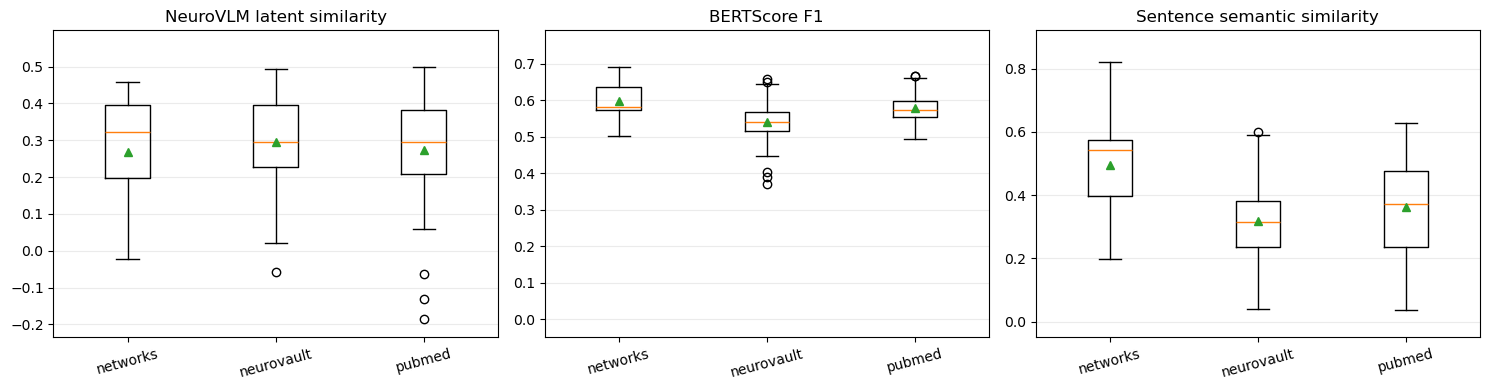

In [19]:
plot_df = b2t_all.copy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_specs = [("nvlm_sim", "NeuroVLM latent similarity"), ("bert_f1", "BERTScore F1"), ("sem_sim", "Sentence semantic similarity")]
for ax, (metric, title) in zip(axes, metric_specs):
    groups = [g[metric].dropna().values for _, g in plot_df.groupby("dataset")]
    labels = [k for k, _ in plot_df.groupby("dataset")]
    ax.boxplot(groups, labels=labels, showmeans=True)
    ax.set_title(title)
    ax.set_ylim(min(-0.05, np.nanmin(plot_df[metric]) - 0.05), min(1.05, np.nanmax(plot_df[metric]) + 0.1))
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "b2t_metric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

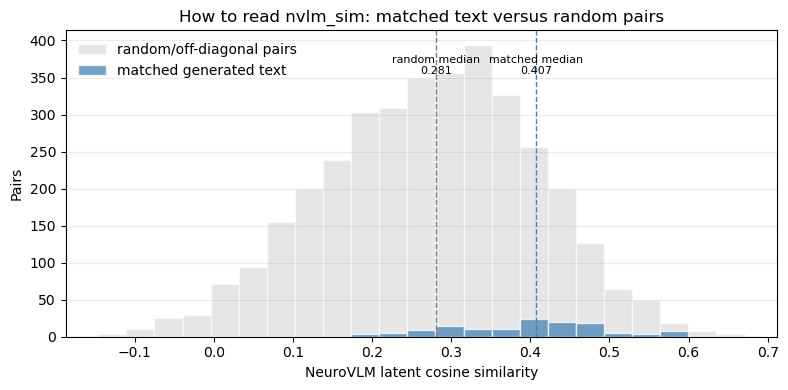

In [20]:
def _brain_latents_for_group(df):
    brain_embs = []
    for _, row in df.iterrows():
        source = row["dataset"]
        name = row["name"]
        if source == "networks":
            brain_embs.append(networks_data[name]["latent"])
        elif source == "pubmed":
            brain_embs.append(next(d["latent"] for d in pubmed_eval if str(d["pmid"]) == str(name)))
        elif source == "neurovault":
            brain_embs.append(next(d["latent"] for d in neurovault_eval if str(d["doi"]) == str(name)))
    return F.normalize(torch.stack([b.cpu() for b in brain_embs]), dim=-1)


def _text_latents_for_group(df):
    nvlm._ensure_projection_heads()
    generated = df["generated"].astype(str).tolist()
    with torch.no_grad():
        raw = nvlm._encode_text(generated)
        z_text = nvlm._proj_head_text_infonce(raw.to(nvlm.device))
        return F.normalize(z_text, dim=-1).cpu()

baseline_rows = []
for (dataset, mode), sub in b2t_all.groupby(["dataset", "mode"]):
    if len(sub) < 2:
        continue
    sub = sub.reset_index(drop=True)
    z_text = _text_latents_for_group(sub)
    z_brain = _brain_latents_for_group(sub)
    scores = z_text @ z_brain.T
    eye = torch.eye(len(sub), dtype=torch.bool)
    for val in scores[eye].numpy():
        baseline_rows.append({"dataset": dataset, "mode": mode, "pair": "matched", "score": float(val)})
    for val in scores[~eye].numpy():
        baseline_rows.append({"dataset": dataset, "mode": mode, "pair": "random/off-diagonal", "score": float(val)})

baseline_df = pd.DataFrame(baseline_rows)
fig, ax = plt.subplots(figsize=(8, 4))
if len(baseline_df):
    matched = baseline_df[baseline_df["pair"] == "matched"]["score"]
    random_pairs = baseline_df[baseline_df["pair"] == "random/off-diagonal"]["score"]
    bins = np.linspace(min(baseline_df["score"].min(), 0), baseline_df["score"].max(), 24)
    ax.hist(random_pairs, bins=bins, alpha=0.55, label="random/off-diagonal pairs", color="lightgray", edgecolor="white")
    ax.hist(matched, bins=bins, alpha=0.75, label="matched generated text", color="steelblue", edgecolor="white")
    for x, lab, color in [(matched.median(), "matched median", "steelblue"), (random_pairs.median(), "random median", "gray")]:
        ax.axvline(x, color=color, linestyle="--", linewidth=1)
        ax.text(x, ax.get_ylim()[1] * 0.92, f"{lab}\n{x:.3f}", ha="center", va="top", fontsize=8)
else:
    vals = b2t_all["nvlm_sim"].dropna()
    ax.hist(vals, bins=min(20, max(5, len(vals) // 2)), alpha=0.75, color="steelblue", edgecolor="white")
    ax.text(0.5, 0.9, "Need at least two samples per group for random-pair baseline", transform=ax.transAxes, ha="center")
ax.set_title("How to read nvlm_sim: matched text versus random pairs")
ax.set_xlabel("NeuroVLM latent cosine similarity")
ax.set_ylabel("Pairs")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "b2t_nvlm_sim_scale.png", dpi=150, bbox_inches="tight")
plt.show()

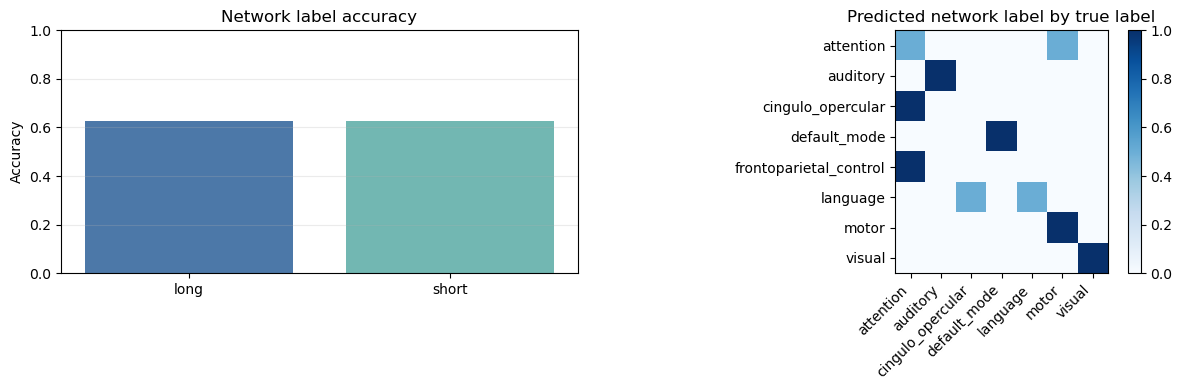

,name,mode,true_network_key,pred_network_key,network_label_correct,label_match_method,generated
0,Language,short,language,cingulo_opercular,False,semantic_low_margin,activation decrease during task processing
1,Language,long,language,language,True,semantic,Activation decrease refers to a reduction in b...
2,Auditory,short,auditory,auditory,True,alias,Auditory processing and abstract condition res...
3,Auditory,long,auditory,auditory,True,semantic,Abstract condition refers to cognitive process...
4,Default Mode,short,default_mode,default_mode,True,alias,Default Mode Network (DMN) regions involved in...
5,Default Mode,long,default_mode,default_mode,True,alias,The Default Mode Network (DMN) is a complex fu...
6,Frontoparietal Control,short,frontoparietal_control,attention,False,semantic,fronto-parietal attentional network
7,Frontoparietal Control,long,frontoparietal_control,attention,False,semantic,Generalized anxiety disorder (GAD) is a psychi...
8,Attention,short,attention,attention,True,semantic,third-party perception involving fronto-pariet...
9,Attention,long,attention,motor,False,alias,Third-party perception refers to the cognitive...


In [21]:
if "network_label_correct" in b2t_all.columns:
    net = b2t_all[b2t_all["dataset"] == "networks"].copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    acc = net.groupby("mode")["network_label_correct"].mean()
    axes[0].bar(acc.index, acc.values, color=["#4c78a8", "#72b7b2"])
    axes[0].set_ylim(0, 1)
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Network label accuracy")
    axes[0].grid(axis="y", alpha=0.25)

    cm = pd.crosstab(net["true_network_key"], net["pred_network_key"], normalize="index")
    im = axes[1].imshow(cm.values, vmin=0, vmax=1, cmap="Blues")
    axes[1].set_xticks(range(len(cm.columns)), cm.columns, rotation=45, ha="right")
    axes[1].set_yticks(range(len(cm.index)), cm.index)
    axes[1].set_title("Predicted network label by true label")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / "b2t_network_label_accuracy.png", dpi=150, bbox_inches="tight")
    plt.show()

    display(net[["name", "mode", "true_network_key", "pred_network_key", "network_label_correct", "label_match_method", "generated"]])